# Olympus sequential benchmark reproducibility

This notebook reproduces the sequential Olympus analyses used in the manuscript. The archived results contain 19 Olympus tasks, five optimizers, 30 independent runs per setting, and 100 evaluations per run.

The task-specific objective ranges used for normalized regret are stored in `olympus_run/configs/tasks/`. The metric implementation has a single source of truth in `reproducibility/metrics.py`.

## Re-run the sequential experiments

First create the three environments described in [`README.md`](README.md). `olympus_run/orchestrator.py` runs the Olympus emulator in the legacy `o11` environment and the optimizer in its corresponding model environment.

A single setting can be reproduced with:

```bash
conda run -n tidyhebo python olympus_run/orchestrator.py \
  --dataset agnp --optimizer tidyhebo \
  --num-iterations 100 --num-runs 30 \
  --output-dir reproduced_results/olympus
```

To reproduce the complete matrix, run the same command for each task listed in `olympus_run/src/tasks.py` and each optimizer in `tidyhebo logei hebo optuna random`. Output files are append-only; always use an empty output directory for a fresh reproduction.

The cells below use the archived results in `02_olympus/`. Change `RESULTS_ROOT` to inspect a newly reproduced directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from reproducibility.metrics import calculate_metrics, load_task_config
from reproducibility.plotting import (
    OPTIMIZER_COLORS,
    OPTIMIZER_LABELS,
    OPTIMIZER_ORDER,
    load_values,
    plot_trajectory,
)
from olympus_run.src.tasks import OLYMPUS_TASKS

ROOT = Path.cwd()
RESULTS_ROOT = ROOT / "02_olympus"
CONFIGS_ROOT = ROOT / "olympus_run" / "configs" / "tasks"

for task in OLYMPUS_TASKS:
    for optimizer in OPTIMIZER_ORDER:
        values = load_values(RESULTS_ROOT / task, optimizer)
        assert values.shape == (30, 100), (task, optimizer, values.shape)

print("Validated 19 tasks × 5 optimizers; every matrix has shape (30, 100).")

Validated 19 tasks × 5 optimizers; every matrix has shape (30, 100).


## Representative optimization trajectories

These four tasks provide a compact view of optimizer behavior on the Olympus emulators. Curves are mean best-so-far objectives across runs with bootstrap 95% confidence intervals. The direction of optimization is taken from each task configuration.

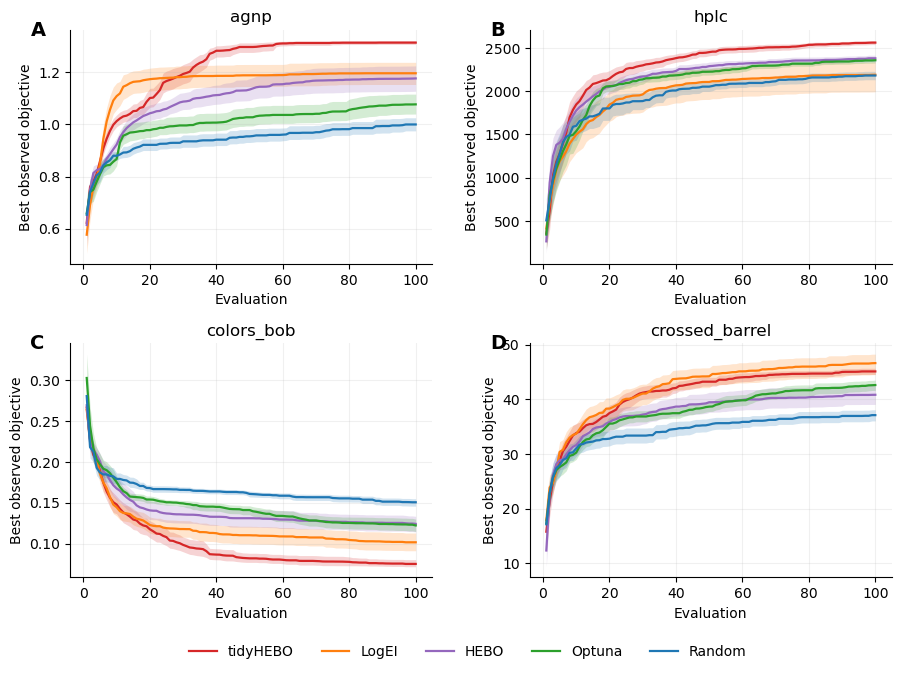

In [2]:
representative_tasks = ("agnp", "hplc", "colors_bob", "crossed_barrel")
fig, axes = plt.subplots(2, 2, figsize=(10.6, 7.2))

for ax, task, panel in zip(axes.flat, representative_tasks, "ABCD"):
    config = load_task_config(task, CONFIGS_ROOT)
    for seed, optimizer in enumerate(OPTIMIZER_ORDER):
        plot_trajectory(
            ax,
            load_values(RESULTS_ROOT / task, optimizer),
            label=OPTIMIZER_LABELS[optimizer],
            color=OPTIMIZER_COLORS[optimizer],
            minimize=bool(config.get("less_is_better", False)),
            seed=seed,
        )
    ax.set_title(task)
    ax.set_xlabel("Evaluation")
    ax.set_ylabel("Best observed objective")
    ax.grid(alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.11, 1.04, panel, transform=ax.transAxes, fontweight="bold", fontsize=14, va="top")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.subplots_adjust(bottom=0.12, wspace=0.27, hspace=0.34)
plt.show()

## Robustness metrics across all Olympus tasks

The table below is the canonical task-by-optimizer summary used by the plotting cells that follow. Lower values are better for `median_nAUC`, `CVaR_nAUC`, and `IQR_nAUC`.

In [3]:
metric_rows = []
for task in OLYMPUS_TASKS:
    config = load_task_config(task, CONFIGS_ROOT)
    for optimizer in OPTIMIZER_ORDER:
        metric_values = calculate_metrics(
            load_values(RESULTS_ROOT / task, optimizer),
            config["y_p_star"],
            config["y_p_w"],
        )
        metric_rows.append({"task": task, "optimizer": optimizer, **metric_values})

metrics = pd.DataFrame(metric_rows)
metrics.head(10).round(4)

,task,optimizer,median_nAUC,IQR_nAUC,CVaR_nAUC
0,hplc,tidyhebo,20.3230,4.4616,26.1470
1,hplc,logei,26.1117,12.0051,72.0357
2,hplc,hebo,23.1420,6.5694,34.3377
3,hplc,optuna,27.2461,6.2680,32.2349
4,hplc,random,31.9802,8.9136,40.8284
5,colors_bob,tidyhebo,7.4856,2.8698,14.7373
6,colors_bob,logei,9.9883,10.9999,19.1609
7,colors_bob,hebo,17.7209,6.8873,23.8129
8,colors_bob,optuna,16.8806,3.7007,20.9919
9,colors_bob,random,21.1862,2.5614,23.5769


## Plotting helpers

Two reusable routines are defined below: `plot_metric_bars` (grouped horizontal bars per task with per-bar annotations and optional clipping) and `plot_mean_rank` (mean task rank per optimizer with SEM bars). Both work directly on the clean `metrics` DataFrame built above.

In [4]:
def plot_metric_bars(
    ax,
    df,
    metric,
    task_order=None,
    value_fmt=".3g",
    clip_value=None,
    clip_prefix="> ",
    label_fontsize=8,
):
    """Grouped horizontal bars: one group per task, one bar per optimizer."""
    if task_order is None:
        task_order = list(df["task"].drop_duplicates())

    n_opt = len(OPTIMIZER_ORDER)
    y = np.arange(len(task_order))
    group_height = 0.78
    bar_height = group_height / n_opt

    for i, optimizer in enumerate(OPTIMIZER_ORDER):
        tmp = (
            df[df["optimizer"] == optimizer]
            .set_index("task")
            .reindex(task_order)
        )
        values = tmp[metric].to_numpy(dtype=float)
        offset = (i - (n_opt - 1) / 2) * bar_height
        ypos = y + offset

        display_values = []
        clipped_flags = []
        for v in values:
            if np.isnan(v):
                display_values.append(np.nan)
                clipped_flags.append(False)
            elif clip_value is not None and v > clip_value:
                display_values.append(clip_value)
                clipped_flags.append(True)
            else:
                display_values.append(v)
                clipped_flags.append(False)

        bars = ax.barh(
            ypos,
            display_values,
            height=bar_height * 0.88,
            color=OPTIMIZER_COLORS[optimizer],
            label=OPTIMIZER_LABELS[optimizer],
        )

        for bar, actual, is_clipped in zip(bars, values, clipped_flags):
            if np.isnan(actual):
                continue
            text = (
                f"{clip_prefix}{actual:{value_fmt}}"
                if is_clipped
                else f"  {actual:{value_fmt}}"
            )
            ax.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                text,
                va="center",
                ha="left",
                fontsize=label_fontsize,
            )

    ax.set_yticks(y, task_order)
    ax.invert_yaxis()
    ax.set_xlabel(metric)
    ax.grid(axis="x", alpha=0.22)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    xmin, xmax = ax.get_xlim()
    if clip_value is not None:
        ax.set_xlim(xmin, max(xmax, clip_value * 1.25))
    else:
        ax.set_xlim(xmin, xmax * 1.12)


def plot_multiple_metric_bars(
    df,
    metrics,
    task_order=None,
    figsize=(14.0, 10.0),
    clip_values=None,
    value_fmt=".3g",
):
    """One panel per metric; each panel is a grouped horizontal bar chart."""
    n_metrics = len(metrics)
    if task_order is None:
        task_order = list(df["task"].drop_duplicates())
    if clip_values is None:
        clip_values = [None] * n_metrics

    fig, axes = plt.subplots(1, n_metrics, figsize=figsize, sharey=True)
    if n_metrics == 1:
        axes = [axes]

    for ax, metric, clip_value in zip(axes, metrics, clip_values):
        plot_metric_bars(
            ax,
            df,
            metric,
            task_order=task_order,
            value_fmt=value_fmt,
            clip_value=clip_value,
        )
        ax.set_title(metric, fontsize=12, fontweight="bold")
        ax.tick_params(axis="y", labelrotation=30, labelsize=10)

    for ax in axes[1:]:
        ax.set_yticklabels([])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(OPTIMIZER_ORDER),
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
    )
    fig.subplots_adjust(left=0.14, bottom=0.09, wspace=0.14)
    return fig, axes


def plot_mean_rank(ax, df, metric, direction="min", show_sem=True):
    """Mean task rank per optimizer with SEM bars (lower rank = better)."""
    tmp = df.copy()
    tmp["rank"] = (
        tmp.groupby("task")[metric]
        .rank(method="average", ascending=(direction == "min"))
    )

    summary = (
        tmp.groupby("optimizer")["rank"]
        .agg(["mean", "std", "count"])
        .reindex(OPTIMIZER_ORDER)
    )
    summary["sem"] = summary["std"] / np.sqrt(summary["count"])

    y = np.arange(len(OPTIMIZER_ORDER))

    for yi in y:
        ax.axhline(yi, color="0.90", linewidth=1.0, zorder=0)
    for rank in range(1, len(OPTIMIZER_ORDER) + 1):
        ax.axvline(rank, color="0.88", linewidth=1.0, zorder=0)

    for yi, optimizer in zip(y, OPTIMIZER_ORDER):
        mean_rank = summary.loc[optimizer, "mean"]
        sem = summary.loc[optimizer, "sem"]
        color = OPTIMIZER_COLORS[optimizer]

        if show_sem and np.isfinite(sem):
            ax.errorbar(
                mean_rank, yi, xerr=sem,
                fmt="none", ecolor=color,
                elinewidth=2.2, capsize=5, capthick=2.0, zorder=2,
            )

        ax.scatter(
            mean_rank, yi, s=160, color=color,
            edgecolor="white", linewidth=1.2, zorder=3,
        )
        ax.text(
            mean_rank + 0.08, yi - 0.16,
            f"{mean_rank:.2f}", fontsize=9, color=color,
        )

    ax.set_yticks(y, [OPTIMIZER_LABELS[o] for o in OPTIMIZER_ORDER])
    for tick, optimizer in zip(ax.get_yticklabels(), OPTIMIZER_ORDER):
        tick.set_color(OPTIMIZER_COLORS[optimizer])
        tick.set_fontweight("bold")

    ax.invert_yaxis()
    ax.set_xlim(0.7, len(OPTIMIZER_ORDER) + 0.3)
    ax.set_xticks(range(1, len(OPTIMIZER_ORDER) + 1))
    ax.set_xlabel("Mean rank (1 = best)")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.18)
    ax.spines[["top", "right", "left"]].set_visible(False)


def plot_multiple_mean_ranks(df, metrics, direction="min", figsize=(12.0, 4.0), show_sem=True):
    """One panel per metric; each panel reports mean task rank per optimizer."""
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize, sharey=True)
    if n_metrics == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        plot_mean_rank(ax, df, metric, direction=direction, show_sem=show_sem)

    for ax in axes[1:]:
        ax.set_yticklabels([])

    fig.subplots_adjust(wspace=0.08)
    return fig, axes

### Task-level metric comparison

Each horizontal group contains the five optimizers for one task. The three panels correspond to the manuscript robustness metrics. Values larger than the panel-specific threshold are clipped and annotated with `>` so the panels remain readable.

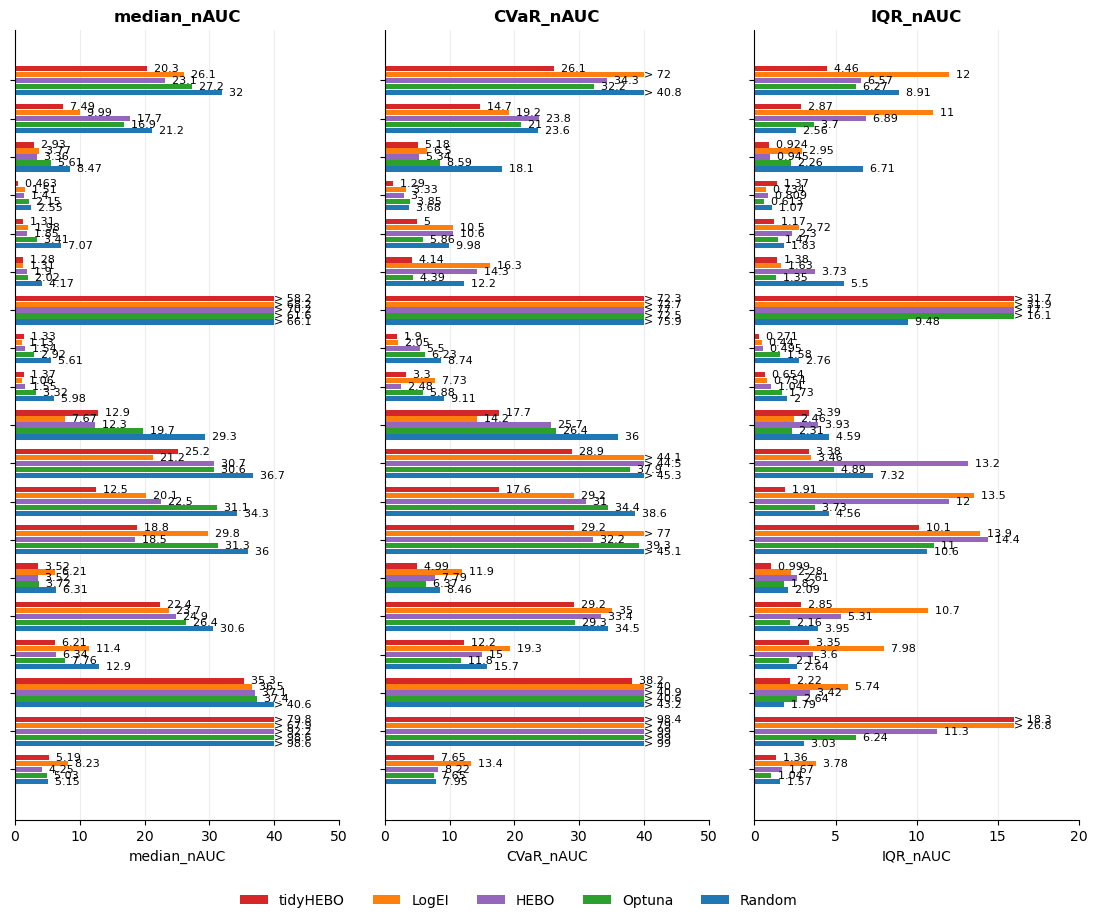

In [5]:
metric_names = ("median_nAUC", "CVaR_nAUC", "IQR_nAUC")
clip_values = (40.0, 40.0, 16.0)

fig, axes = plot_multiple_metric_bars(
    metrics,
    list(metric_names),
    task_order=list(OLYMPUS_TASKS),
    figsize=(14.0, 10.0),
    clip_values=list(clip_values),
)
plt.show()

### Mean optimizer rank

For each task and metric, rank 1 is assigned to the lowest (best) metric value. The plot reports the mean task rank and its standard error across the 19 tasks. The metrics are aggregated via ranks to avoid the scale differences between tasks dominating the summary.

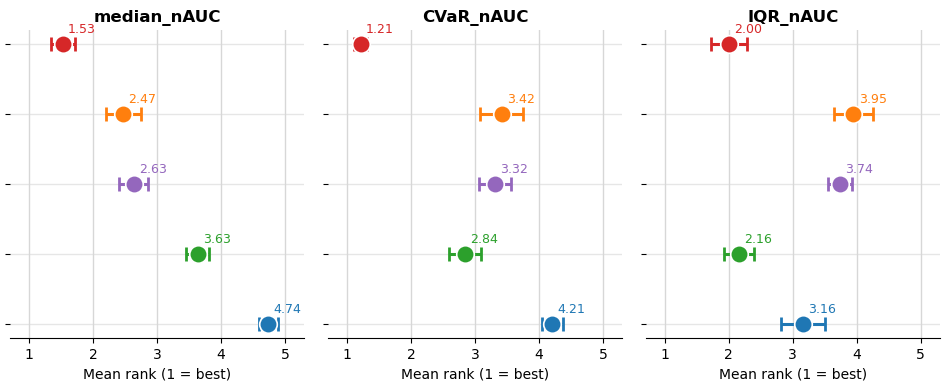

In [6]:
fig, axes = plot_multiple_mean_ranks(
    metrics,
    list(metric_names),
    direction="min",
    figsize=(12.0, 4.0),
)
plt.show()

### Aggregated means / medians

For completeness, the cell below reports mean and median metric values per optimizer across all tasks. Because the raw metric scales differ strongly between tasks, prefer the mean-rank summary above for qualitative comparisons.

In [7]:
agg_both = (
    metrics.groupby("optimizer")
    .agg({
        "median_nAUC": ["mean", "median"],
        "IQR_nAUC": ["mean", "median"],
        "CVaR_nAUC": ["mean", "median"],
    })
    .reindex(OPTIMIZER_ORDER)
)
agg_both

median_nAUC             IQR_nAUC            CVaR_nAUC           
                 mean     median      mean    median       mean     median
optimizer                                                                 
tidyhebo    16.654270   7.485578  4.873916  2.217475  21.990165  14.737336
logei       18.310907   9.988279  8.146546  3.776335  30.172335  19.160929
hebo        19.731259  12.279554  5.854450  3.726849  27.058498  23.812855
optuna      21.938312  16.880569  3.849425  2.256627  25.957168  20.991895
random      25.447506  21.186212  4.368092  3.032455  30.307538  23.576854